In [27]:
import matplotlib.pyplot as plt
import numpy as np
from dataset import uciDataset, get_dataloader
from diffusion import Diffusion
import torch
from tqdm import tqdm
from mlp import ScoreModel
import gpytorch

In [57]:
dataset = uciDataset("elevators", x_normalise=True, y_normalise=True)
train_loader, val_loader, test_loader = get_dataloader(dataset, batch_size=64, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)

print(dataset.X.dtype, dataset.X.shape)
print(dataset.y.dtype, dataset.y.shape)

torch.float32 torch.Size([16599, 18])
torch.float32 torch.Size([16599])


# GP with inducing points

In [122]:
class DiffusionGP(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_dist = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_dist, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)

        input_size = inducing_points.size(1)
        x_dims = input_size - 2  # Last 2 dims are for t and y_t
        
        # Same kernel: product over x, t, y_t
        self.mean_module = gpytorch.means.LinearMean(input_size=input_size)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.ProductKernel(
                gpytorch.kernels.MaternKernel(nu=1.5, active_dims=list(range(x_dims))),  # x
                gpytorch.kernels.MaternKernel(nu=0.5, active_dims=[x_dims]),  # t
                gpytorch.kernels.MaternKernel(nu=0.5, active_dims=[x_dims + 1]),   # y_t
            ), 
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [116]:
num_epochs = 200
time_steps = 1000
epoch_update = 10
total_dim = dataset.X.shape[1] + 2
loss_type = "elbo"
num_inducing_points = 800
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# initialise model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
inducing_points = torch.rand(num_inducing_points, total_dim).to(device)
model = DiffusionGP(inducing_points).to(device)
likelihood = likelihood.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
diffusion = Diffusion(T=time_steps, device=device)


best_val_loss = float('inf')
train_losses = []
val_losses = []
if loss_type == "elbo":
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_loader.dataset))
elif loss_type == "mse":
    mll = torch.nn.MSELoss()

# training loop
model.train()
likelihood.train()
for epoch in range(num_epochs):
    train_epoch_loss = 0
    train_num_batches = 0

    for batch in train_loader:
        x = batch['X'].to(device)
        y_0 = batch['y'].to(device)
        t = torch.randint(1, time_steps, (x.shape[0],), device=device)
        noise = torch.randn_like(y_0, device=device)
        y_t = diffusion.q_sample(y_0, t, noise)
        t = t / time_steps # normalise time step

        # Stack x, t, y_t
        t = t.unsqueeze(1)
        if y_t.dim() == 1:
            y_t = y_t.unsqueeze(1)
        z = torch.cat([x, t, y_t], dim=1)

        # Forward pass
        output = model(z)
        if loss_type == "elbo":
            loss = -mll(output, noise)
        elif loss_type == "mse":
            loss = mll(output.mean, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_epoch_loss += loss.item()
        train_num_batches += 1
        
    train_losses.append(train_epoch_loss / train_num_batches)

    # Validation phase
    model.eval()
    likelihood.eval()
    val_epoch_loss = 0
    val_num_batches = 0
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for batch in val_loader:
            x = batch['X'].to(device)
            y_0 = batch['y'].to(device)
            t = torch.randint(1, time_steps, (x.shape[0],), device=device)
            noise = torch.randn_like(y_0, device=device)
            y_t = diffusion.q_sample(y_0, t, noise)
            t = t / time_steps # normalise time step
        
            # Stack x, t, y_t
            t = t.unsqueeze(1)
            if y_t.dim() == 1:
                y_t = y_t.unsqueeze(1)
            z = torch.cat([x, t, y_t], dim=1)

            # Forward pass
            output = model(z)
            if loss_type == "elbo":
                loss = -mll(output, noise)
            elif loss_type == "mse":
                loss = mll(output.mean, noise)
            val_epoch_loss += loss.item()
            val_num_batches += 1
    val_losses.append(val_epoch_loss / val_num_batches)
    
    if epoch % epoch_update == 0:
        print(f'Epoch {epoch}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

Epoch 0/200, Train Loss: 6.6342, Val Loss: 1.2930


/opt/anaconda3/envs/dgp/lib/python3.11/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-06.
  warnings.warn(


Epoch 10/200, Train Loss: 1.4779, Val Loss: 0.9671
Epoch 20/200, Train Loss: 0.9638, Val Loss: 0.9570
Epoch 30/200, Train Loss: 0.9417, Val Loss: 0.9455
Epoch 40/200, Train Loss: 0.9283, Val Loss: 0.9230
Epoch 50/200, Train Loss: 0.9304, Val Loss: 0.9219
Epoch 60/200, Train Loss: 0.9362, Val Loss: 0.9274
Epoch 70/200, Train Loss: 0.9279, Val Loss: 0.9214
Epoch 80/200, Train Loss: 0.9266, Val Loss: 0.9146
Epoch 90/200, Train Loss: 0.9242, Val Loss: 0.9299
Epoch 100/200, Train Loss: 0.9319, Val Loss: 0.9359
Epoch 110/200, Train Loss: 0.9201, Val Loss: 0.9187
Epoch 120/200, Train Loss: 0.9284, Val Loss: 0.9275
Epoch 130/200, Train Loss: 0.9261, Val Loss: 0.9175
Epoch 140/200, Train Loss: 0.9248, Val Loss: 0.9552
Epoch 150/200, Train Loss: 0.9381, Val Loss: 0.9108
Epoch 160/200, Train Loss: 0.9209, Val Loss: 0.9116
Epoch 170/200, Train Loss: 0.9256, Val Loss: 0.9261
Epoch 180/200, Train Loss: 0.9220, Val Loss: 0.9350
Epoch 190/200, Train Loss: 0.9192, Val Loss: 0.9077


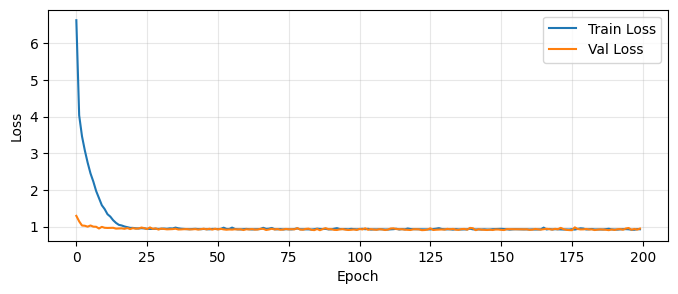

In [117]:
plt.figure(figsize=(8, 3))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
# plt.ylim(0.5,2)
plt.legend()
plt.show()

In [118]:
time_steps = 1000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# average test loss
test_loss = 0
predictions = []
true_values = []

with tqdm(total=len(test_loader)) as pbar:
    for batch in test_loader:
        x = batch['X'].to(device)
        y_0 = batch['y'].to(device)
        y_t = torch.randn_like(y_0, device=device)

        model.eval()
        likelihood.eval()
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            for t in range(time_steps-1, -1, -1):
                t_tensor = torch.ones_like(y_t) * (t+1)
                t_tensor = t_tensor / time_steps

                # Stack x, t, y_t   
                if y_t.dim() == 1:
                    y_t = y_t.unsqueeze(1)
                if t_tensor.dim() == 1:
                    t_tensor = t_tensor.unsqueeze(1)
                z = torch.cat([x, t_tensor, y_t], dim=1)
                score = model(z).mean
                y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score.unsqueeze(1))
                y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])

        predictions.append(y_t)
        true_values.append(y_0)
        pbar.update(1)

predictions = torch.cat(predictions, dim=0).flatten()
true_values = torch.cat(true_values, dim=0)

100%|██████████| 26/26 [00:40<00:00,  1.57s/it]


In [119]:
rmse = torch.sqrt(torch.mean((true_values - predictions)**2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.7122


In [120]:
# scale the predictions and true values
y_scaler = dataset.y_scaler
predictions_scaled = y_scaler.inverse_transform(predictions.reshape(-1,1))
true_values_scaled = y_scaler.inverse_transform(true_values.reshape(-1,1))

/var/folders/sq/_ygl92r55ks2__x_h38qg7h00000gn/T/ipykernel_5800/4132184227.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


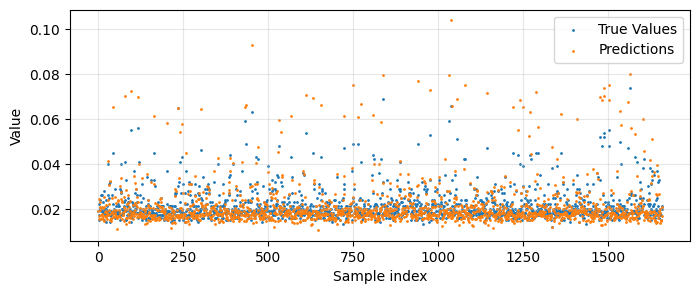

In [121]:
plt.figure(figsize=(8, 3))
plt.grid(alpha=0.3)
# plt.ylim(0.5,2)
plt.legend()
plt.xlabel('Sample index')
plt.ylabel('Value')
plt.scatter(range(len(true_values_scaled)), true_values_scaled,s=1, label='True Values')
plt.scatter(range(len(predictions_scaled)), predictions_scaled,s=1, label='Predictions')
plt.legend()
plt.show()

# GP with SDD